# 🎓 Детектирование бейджей — YOLOv8
**Дипломная работа. Обучение и детектирование в Google Colab (GPU T4)**

### Порядок работы:
1. `Runtime → Change runtime type → T4 GPU`
2. Запускай ячейки по порядку
3. Загрузи свои датасеты в ячейке **«Загрузка датасетов»**
4. После обучения скачай `best.pt` из ячейки **«Сохранение»**

## 0. Проверка GPU

In [ ]:
import torch

print(f'PyTorch: {torch.__version__}')
print(f'CUDA доступна: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  GPU не найден — зайди в Runtime → Change runtime type → T4 GPU')

PyTorch: 2.10.0+cu128
CUDA доступна: True
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Установка зависимостей

In [ ]:
!pip install ultralytics roboflow -q
print('✅ Готово')

✅ Готово


## 2. Загрузка датасетов с Google Drive


In [ ]:
# Монтируем Google Drive
from google.colab import drive
drive.mount("/content/drive")

import os, shutil, glob
from pathlib import Path

# Путь к папке dataset на твоём Drive
# Если структура другая — поменяй путь
DRIVE_DATASET_DIR = "/content/drive/MyDrive/dataset"

# Копируем датасеты в /content/datasets (быстрый локальный диск)
# Это нужно чтобы обучение не тормозило из-за Drive IO
os.makedirs("/content/datasets", exist_ok=True)

dataset_dirs = [p.rstrip("/") for p in glob.glob(f"{DRIVE_DATASET_DIR}/*/")]
print(f"Найдено датасетов на Drive: {len(dataset_dirs)}")

for ds_path in dataset_dirs:
    ds_name = Path(ds_path).name
    dst = f"/content/datasets/{ds_name}"
    if Path(dst).exists():
        print(f"  {ds_name} — уже скопирован, пропуск")
        continue
    print(f"  Копирую {ds_name}...")
    shutil.copytree(ds_path, dst)

print("✅ Все датасеты скопированы в /content/datasets")


Mounted at /content/drive
Найдено датасетов на Drive: 15
  Копирую ocr-97dzn...
  Копирую pendeteksi-id-card-event...
  Копирую nametag...
  Копирую nametag-6uhm1...
  Копирую id-card-rggee...
  Копирую id-card-detections...
  Копирую id-card-ecsnq...
  Копирую id-card-l8shn...
  Копирую name-badge-detection...
  Копирую id-card-go7hc...
  Копирую face-and-badge-dedection...
  Копирую badge-detection-xyytk...
  Копирую badge-detection-ykp7o...
  Копирую badge-detection-full-ecqi4...
  Копирую badge-detection-bx6ja...
✅ Все датасеты скопированы в /content/datasets


## 3. Объединение датасетов

In [ ]:
import shutil
import glob
from pathlib import Path

MERGED_DIR = Path('/content/dataset_merged')

def merge_datasets(dataset_dirs, merged_dir):
    merged = Path(merged_dir)
    for split in ('train', 'valid', 'test'):
        (merged / 'images' / split).mkdir(parents=True, exist_ok=True)
        (merged / 'labels' / split).mkdir(parents=True, exist_ok=True)

    img_count = 0
    for ds_path in dataset_dirs:
        ds = Path(ds_path)
        for split in ('train', 'valid', 'test'):
            img_src = ds / split / 'images'
            lbl_src = ds / split / 'labels'
            if not img_src.exists():
                continue
            for img_file in img_src.glob('*.[jp][pn]g'):
                new_name = f'{ds.name}__{img_file.name}'
                shutil.copy2(img_file, merged / 'images' / split / new_name)
                lbl_file = lbl_src / (img_file.stem + '.txt')
                dst_lbl = merged / 'labels' / split / f'{ds.name}__{img_file.stem}.txt'
                if lbl_file.exists():
                    lines = lbl_file.read_text().splitlines()
                    new_lines = ['0 ' + ' '.join(l.strip().split()[1:])
                                 for l in lines if len(l.strip().split()) >= 5]
                    dst_lbl.write_text('\n'.join(new_lines))
                else:
                    dst_lbl.write_text('')
                img_count += 1

    # Статистика
    for split in ('train', 'valid', 'test'):
        n = len(list((merged / 'images' / split).glob('*.[jp][pn]g')))
        print(f'  {split}: {n} изображений')

    # data.yaml — абсолютные пути, без поля path
    abs_merged = merged.resolve()
    train_path = str(abs_merged / 'images' / 'train')
    val_path   = str(abs_merged / 'images' / 'valid')
    test_path  = str(abs_merged / 'images' / 'test')
    if not any((abs_merged / 'images' / 'valid').glob('*.[jp][pn]g')):
        print('  valid пустой → используем train для валидации')
        val_path = train_path

    yaml_path = merged / 'data.yaml'
    yaml_path.write_text(
        f'train: {train_path}\nval: {val_path}\ntest: {test_path}\nnc: 1\nnames: [badge]\n'
    )
    print(f'\nВсего объединено: {img_count} изображений')
    print(f'data.yaml: {yaml_path}')
    return str(yaml_path)


dataset_dirs = [p.rstrip('/') for p in glob.glob('/content/datasets/*/')]
print(f'Найдено датасетов: {len(dataset_dirs)}')
for d in dataset_dirs:
    print(f'  {Path(d).name}')

DATA_YAML = merge_datasets(dataset_dirs, MERGED_DIR)

Найдено датасетов: 15
  id-card-l8shn
  nametag
  badge-detection-ykp7o
  pendeteksi-id-card-event
  face-and-badge-dedection
  id-card-go7hc
  id-card-ecsnq
  id-card-rggee
  id-card-detections
  badge-detection-xyytk
  name-badge-detection
  badge-detection-bx6ja
  badge-detection-full-ecqi4
  ocr-97dzn
  nametag-6uhm1
  train: 3924 изображений
  valid: 445 изображений
  test: 296 изображений

Всего объединено: 4665 изображений
data.yaml: /content/dataset_merged/data.yaml


## 4. Обучение YOLOv8

In [ ]:
from ultralytics import YOLO

# yolov8n = nano (быстро, ~6MB)
# yolov8s = small (точнее, ~22MB)
# yolov8m = medium (ещё точнее, ~50MB) — выбирай по времени
MODEL_SIZE = 'n'
EPOCHS     = 50
IMGSZ      = 640
BATCH      = 32   # на T4 можно 32, на CPU было 16

model = YOLO(f'yolov8{MODEL_SIZE}.pt')

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    project='/content/runs',
    name='badge_detector',
    pretrained=True,
    patience=15,
    save=True,
    plots=True,
    val=True,
    exist_ok=True,
    device=0,   # явно указываем GPU 0
)

BEST_PT = '/content/runs/badge_detector/weights/best.pt'
print(f'\n✅ Обучение завершено!')
print(f'mAP50:    {results.results_dict.get("metrics/mAP50(B)", 0):.4f}')
print(f'mAP50-95: {results.results_dict.get("metrics/mAP50-95(B)", 0):.4f}')
print(f'Веса:     {BEST_PT}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_merged/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, i

## 5. Графики обучения

/content/runs/badge_detector/BoxF1_curve.png


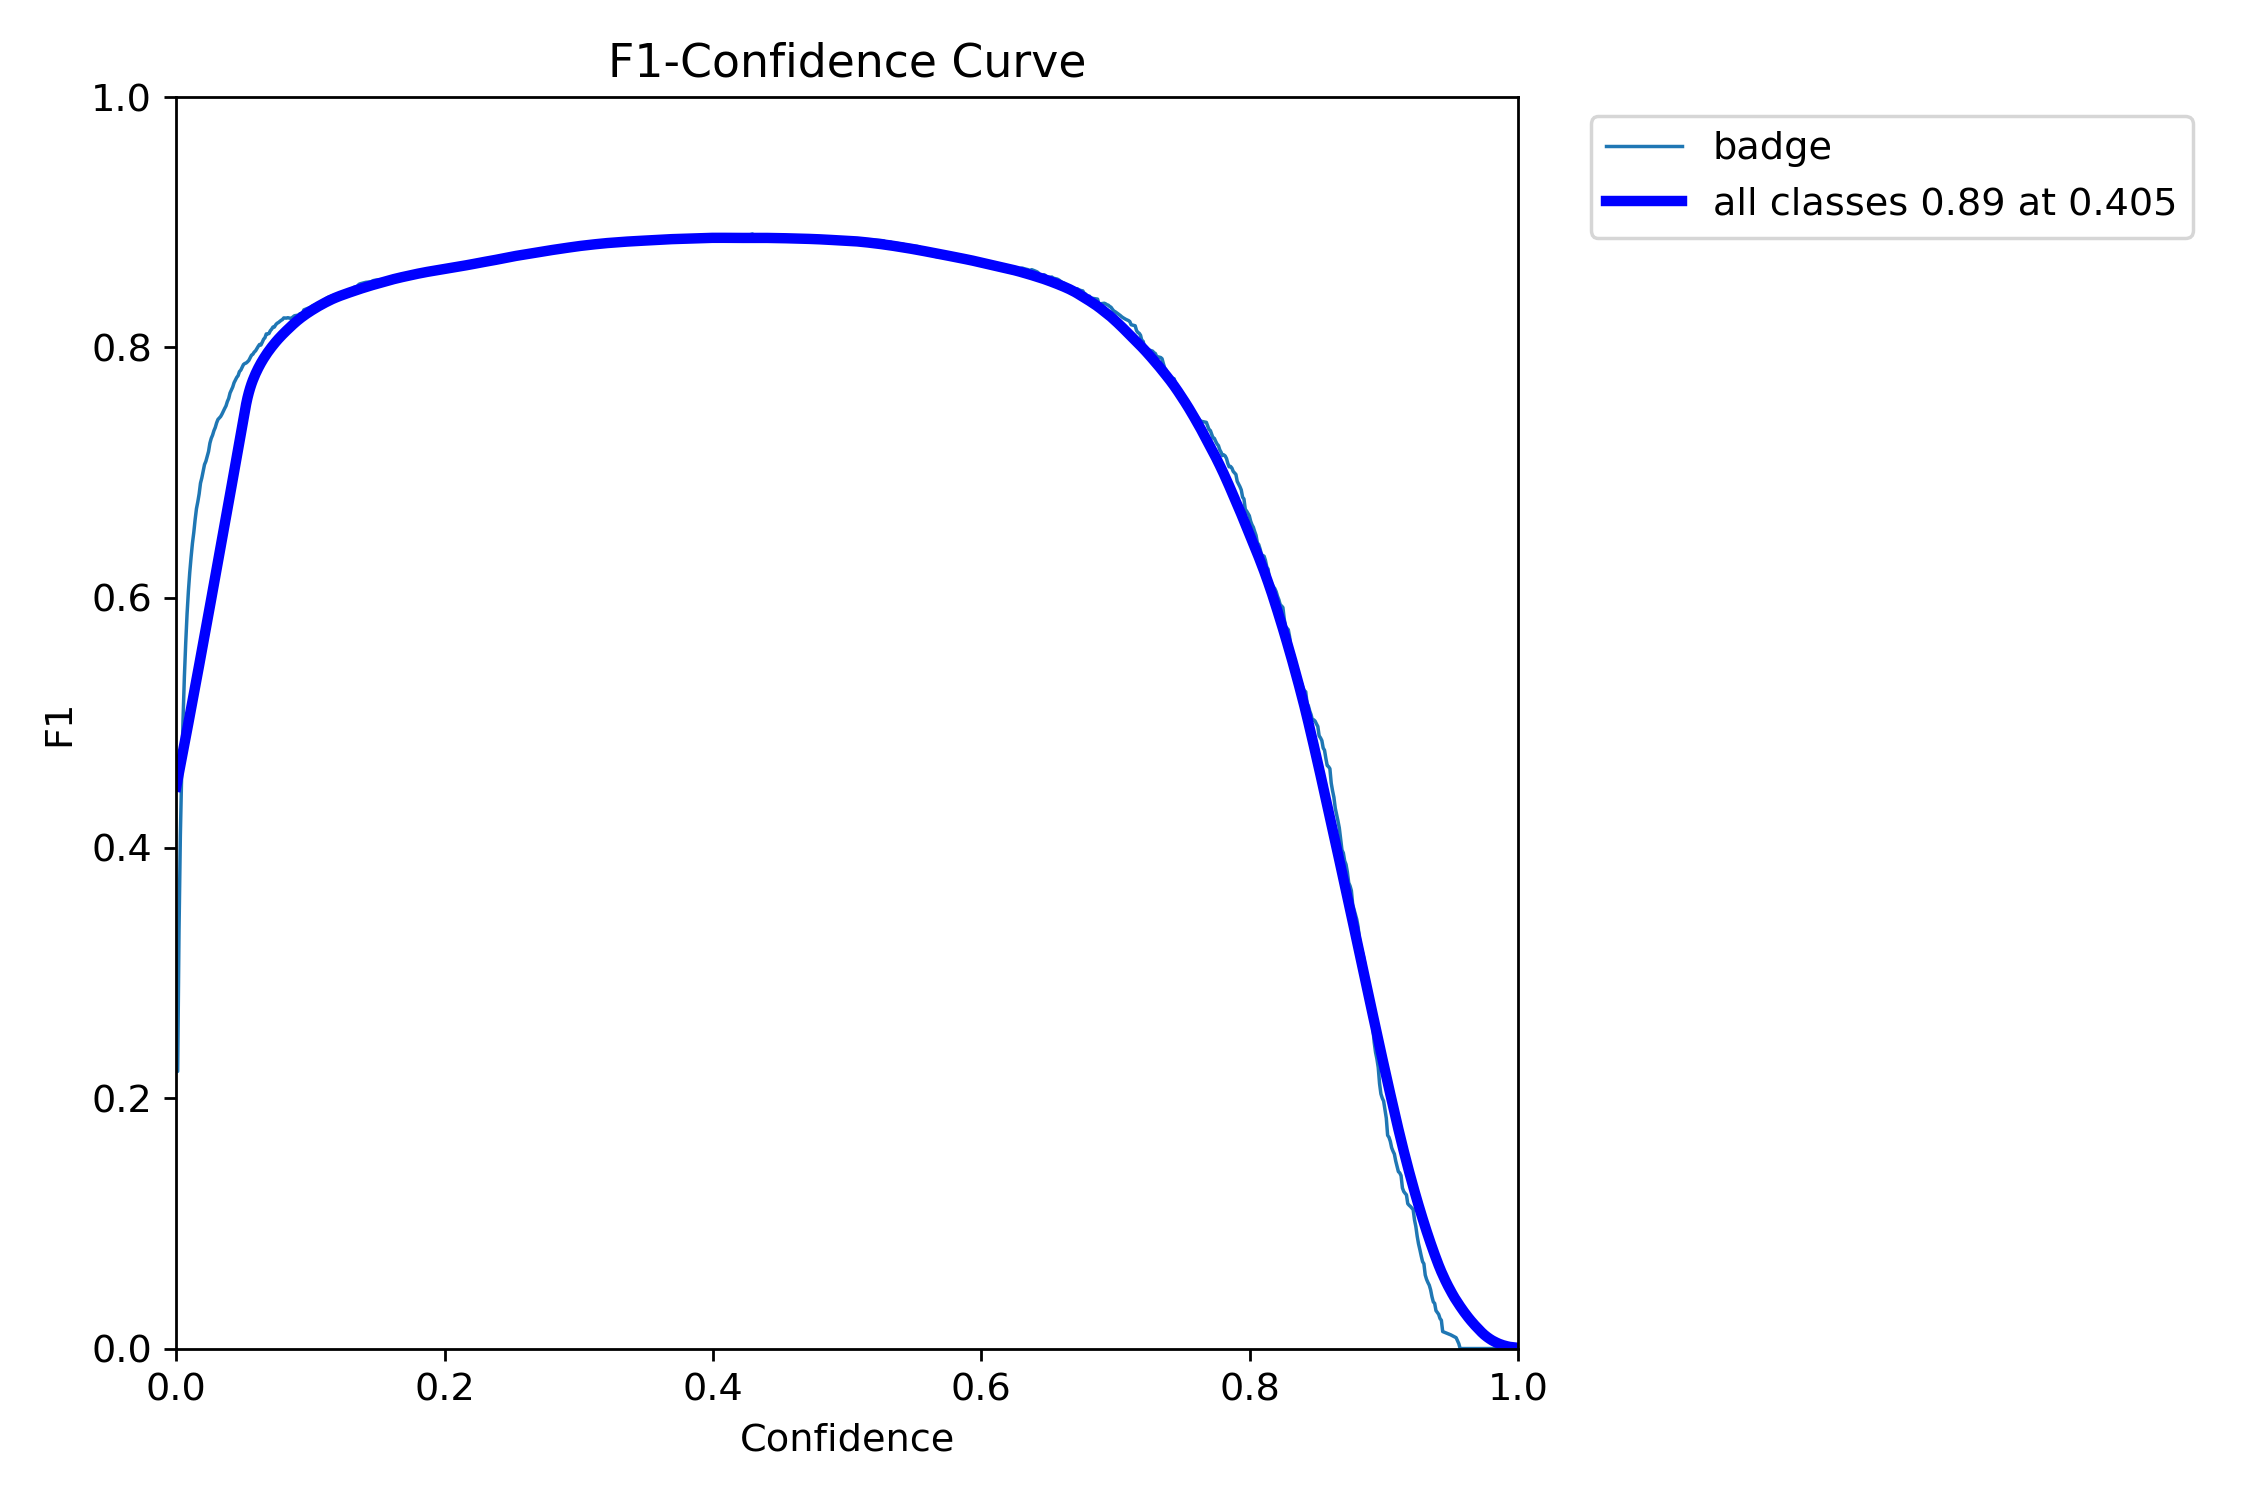

/content/runs/badge_detector/BoxPR_curve.png


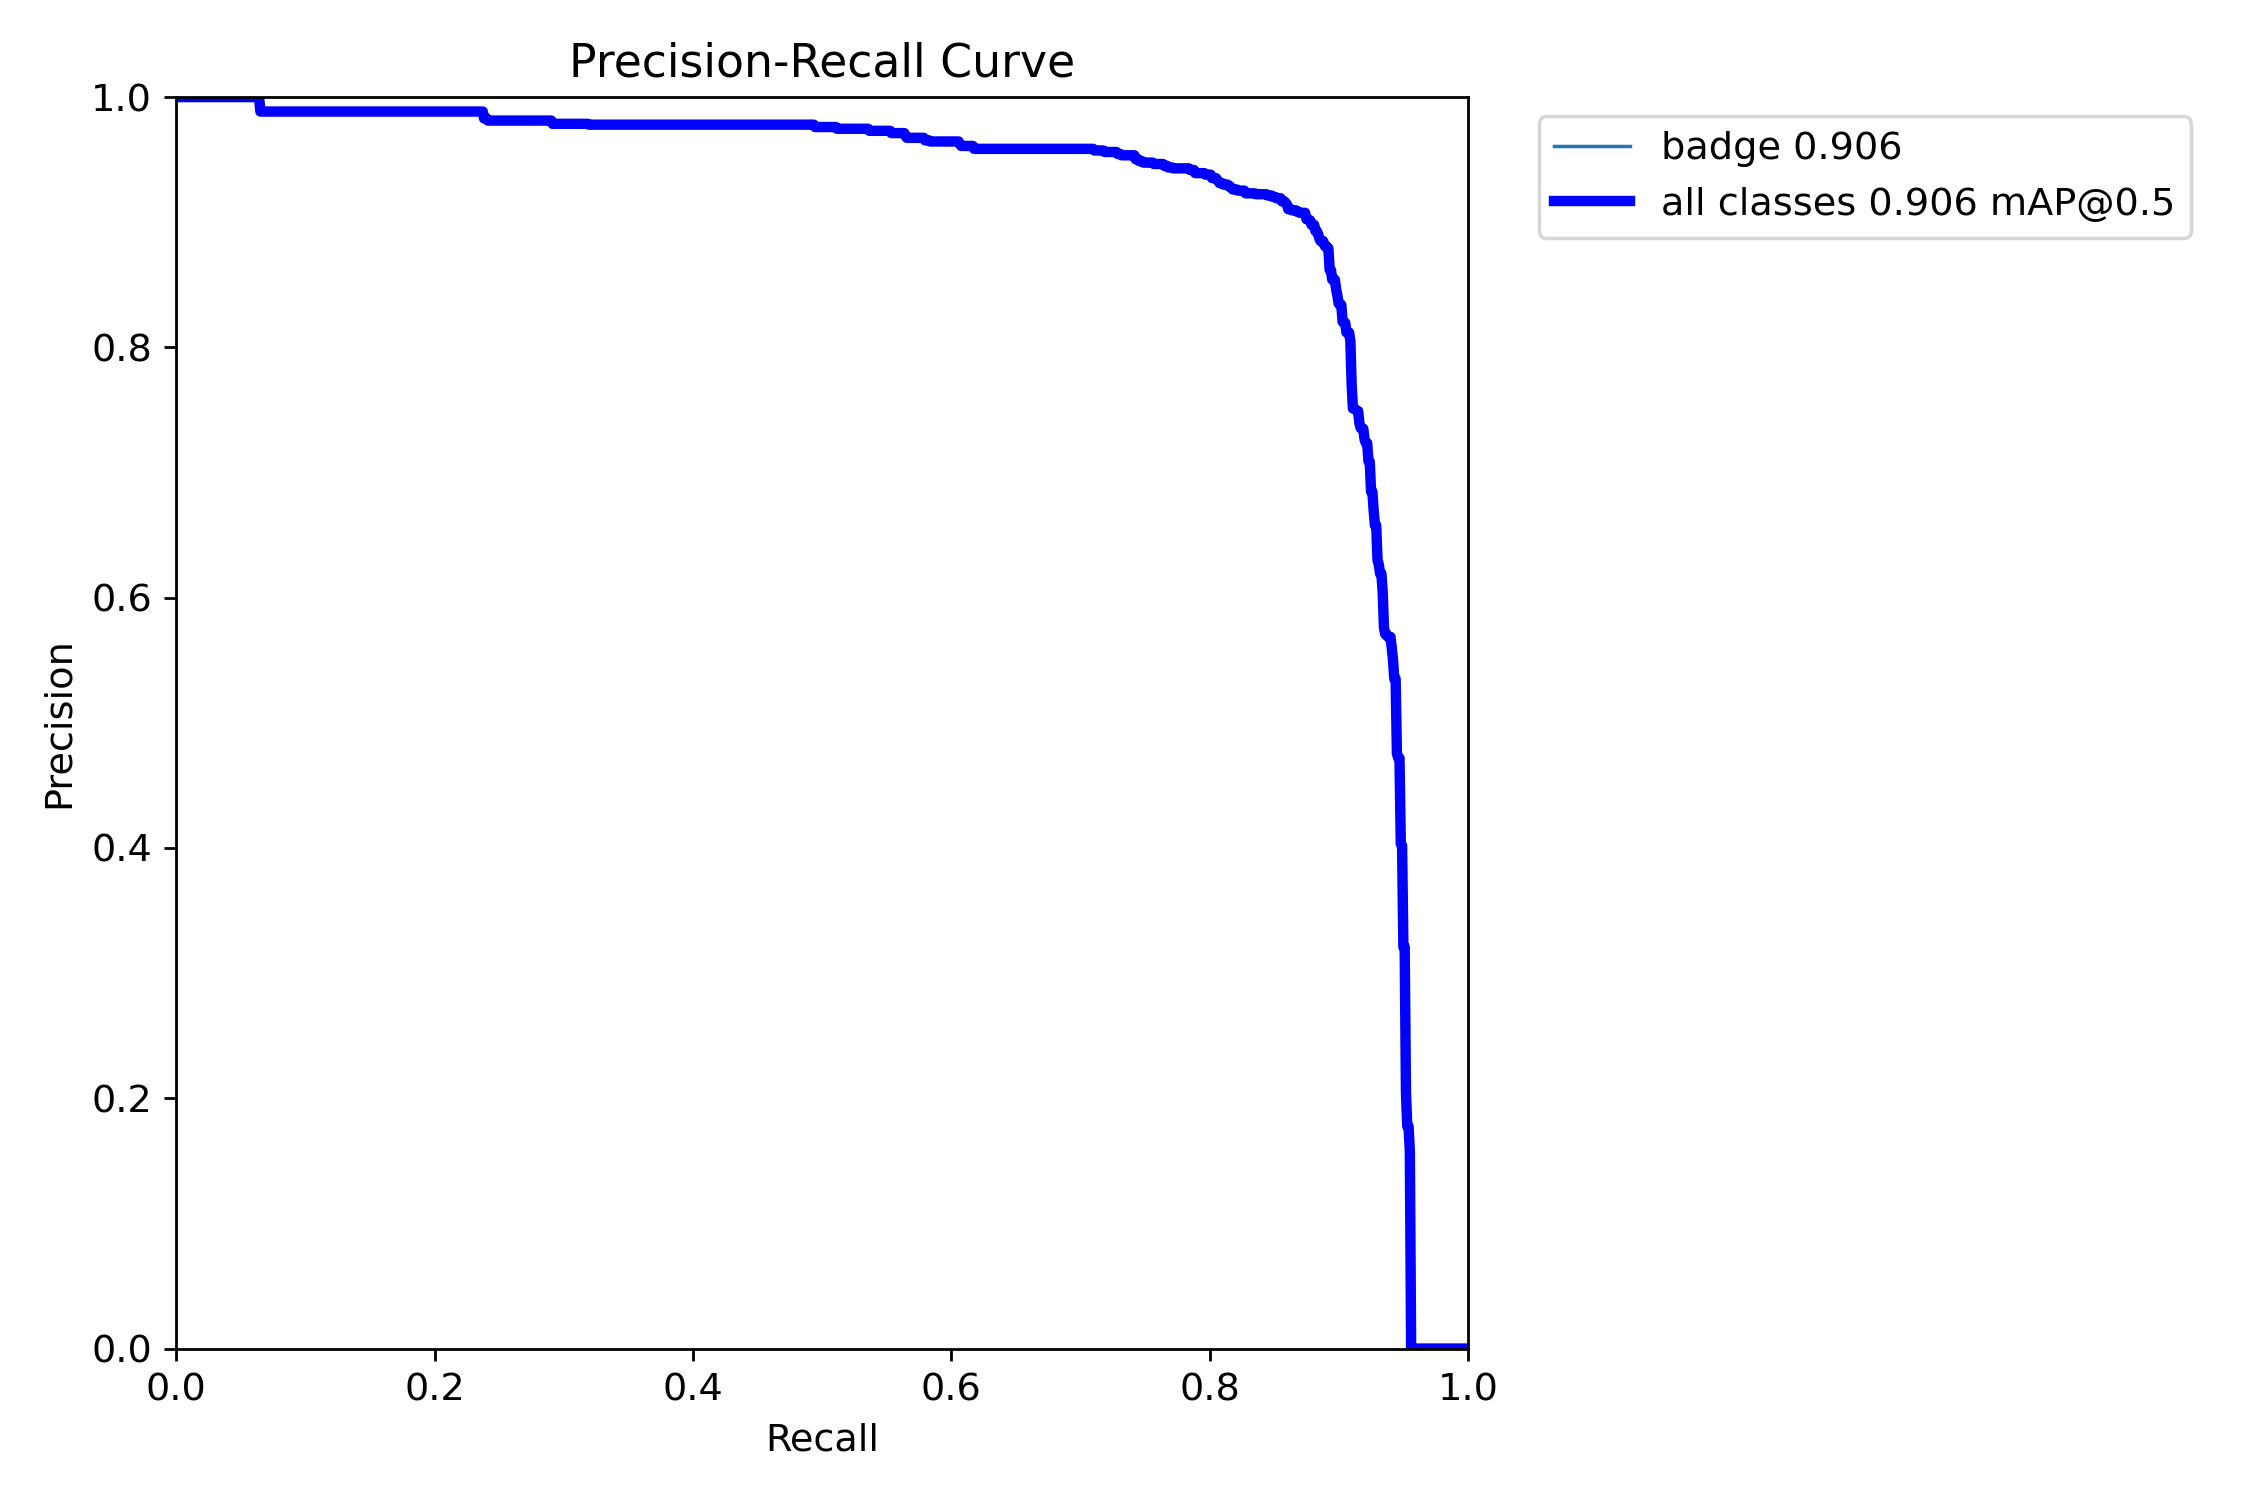

/content/runs/badge_detector/BoxP_curve.png


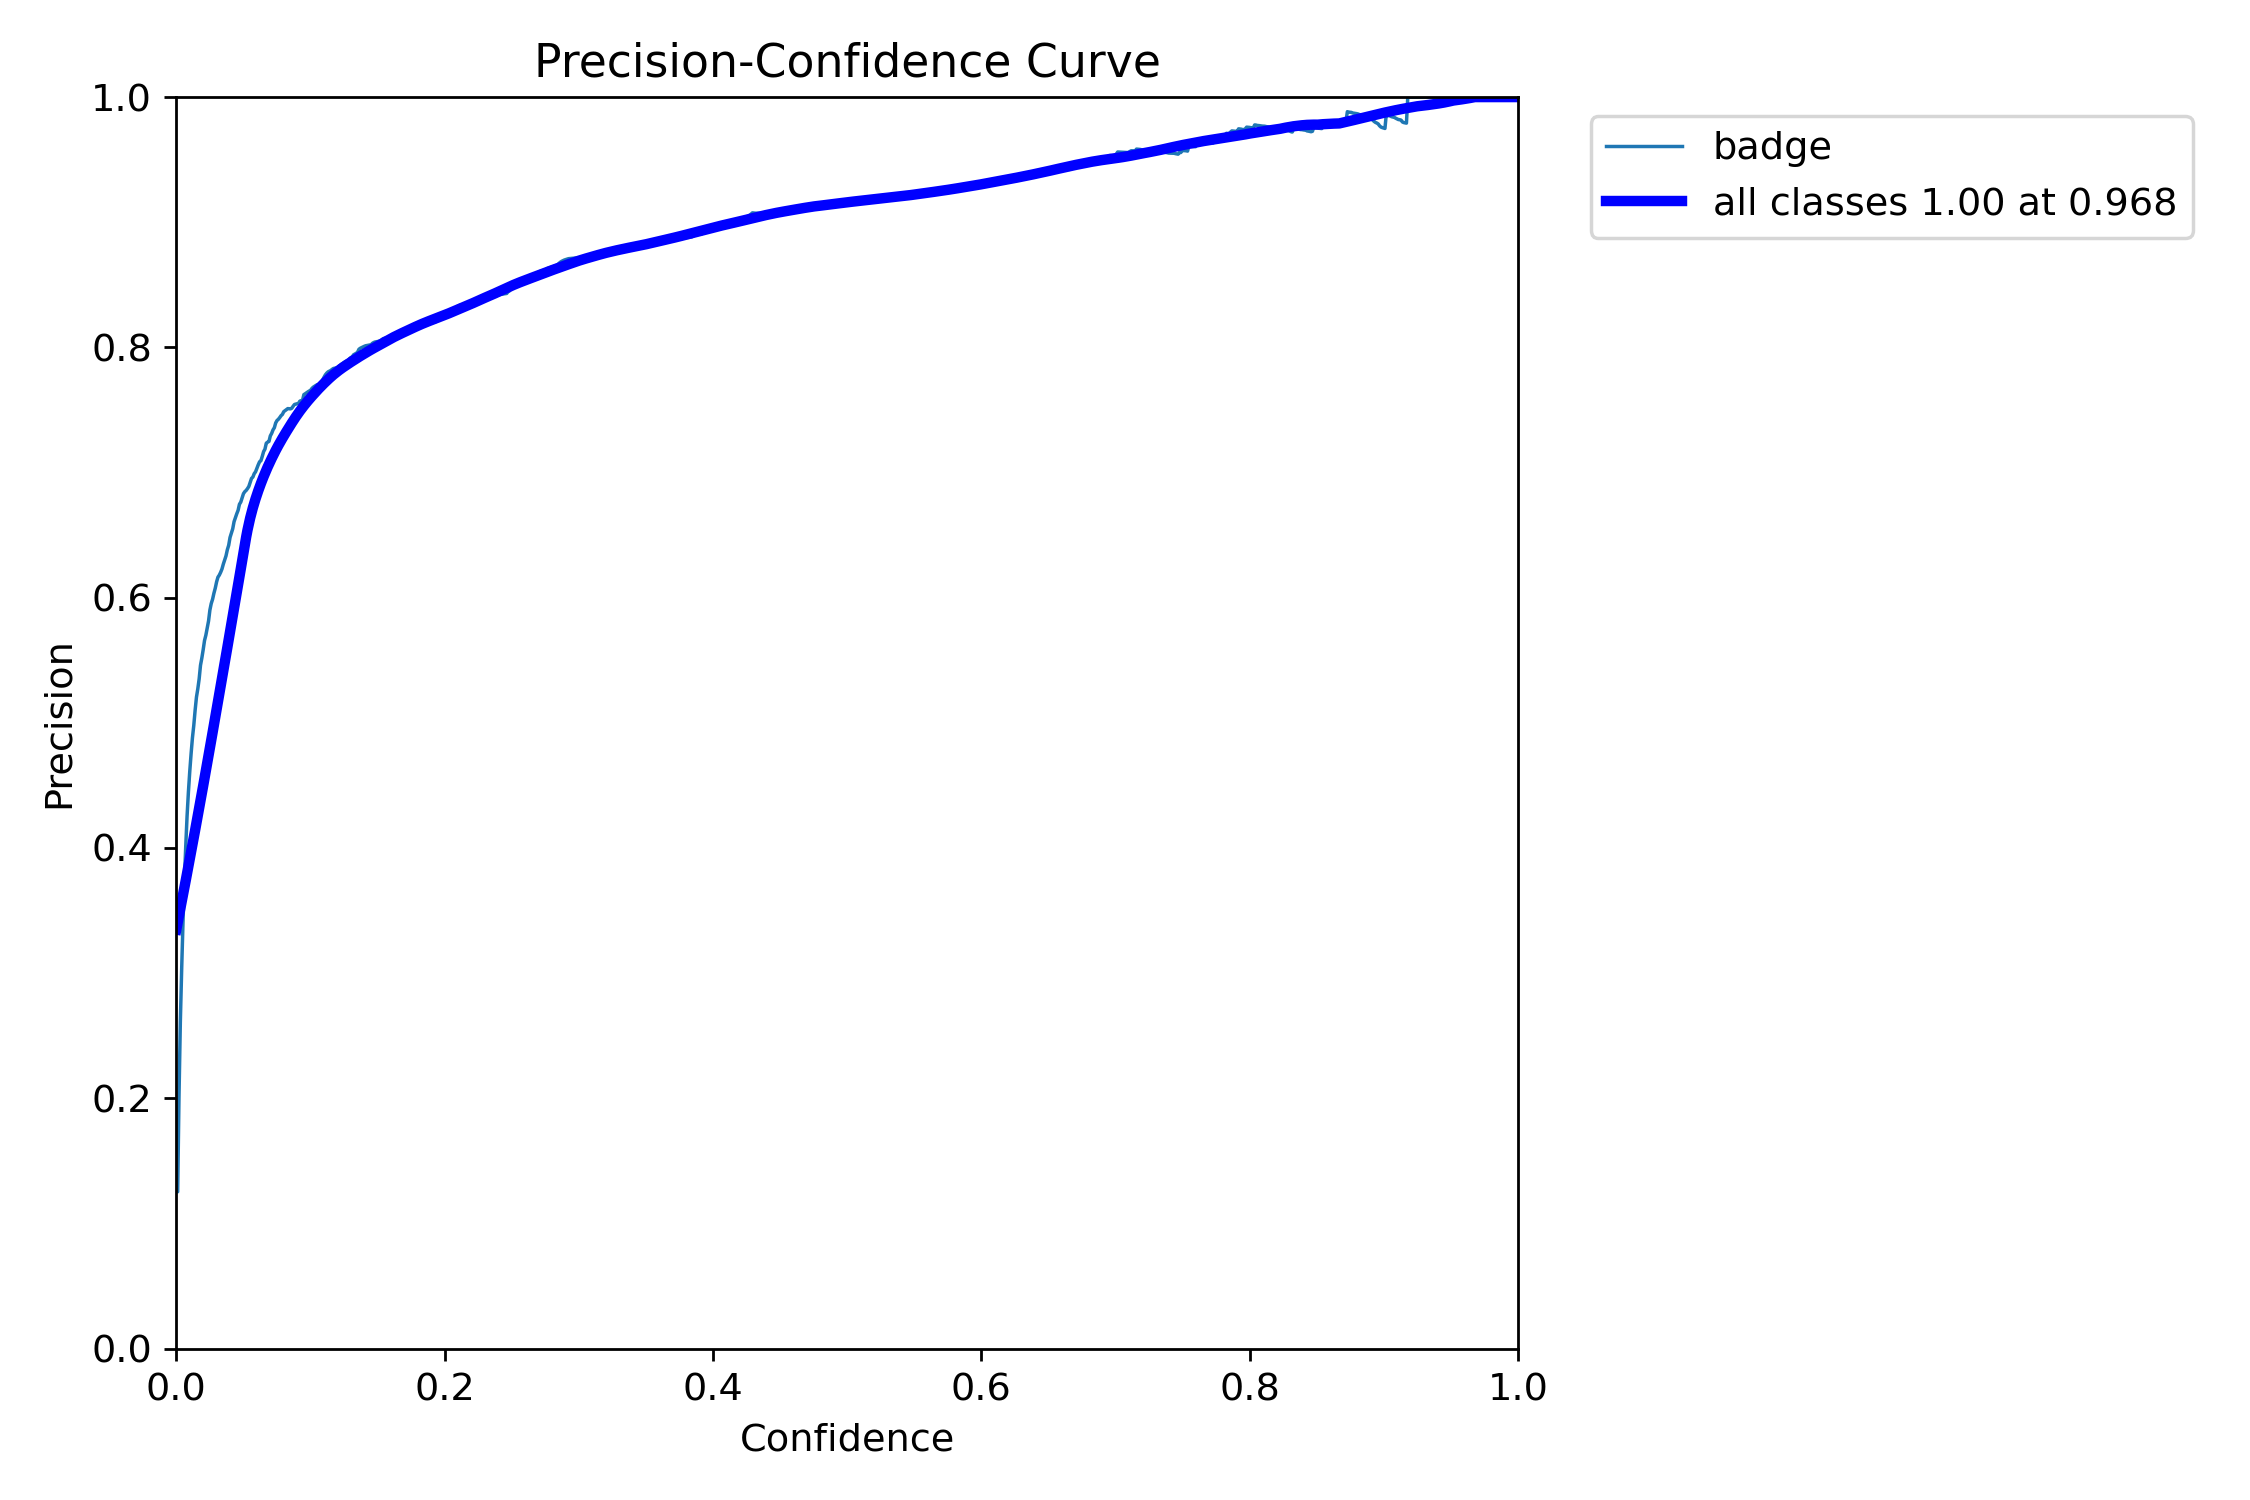

/content/runs/badge_detector/BoxR_curve.png


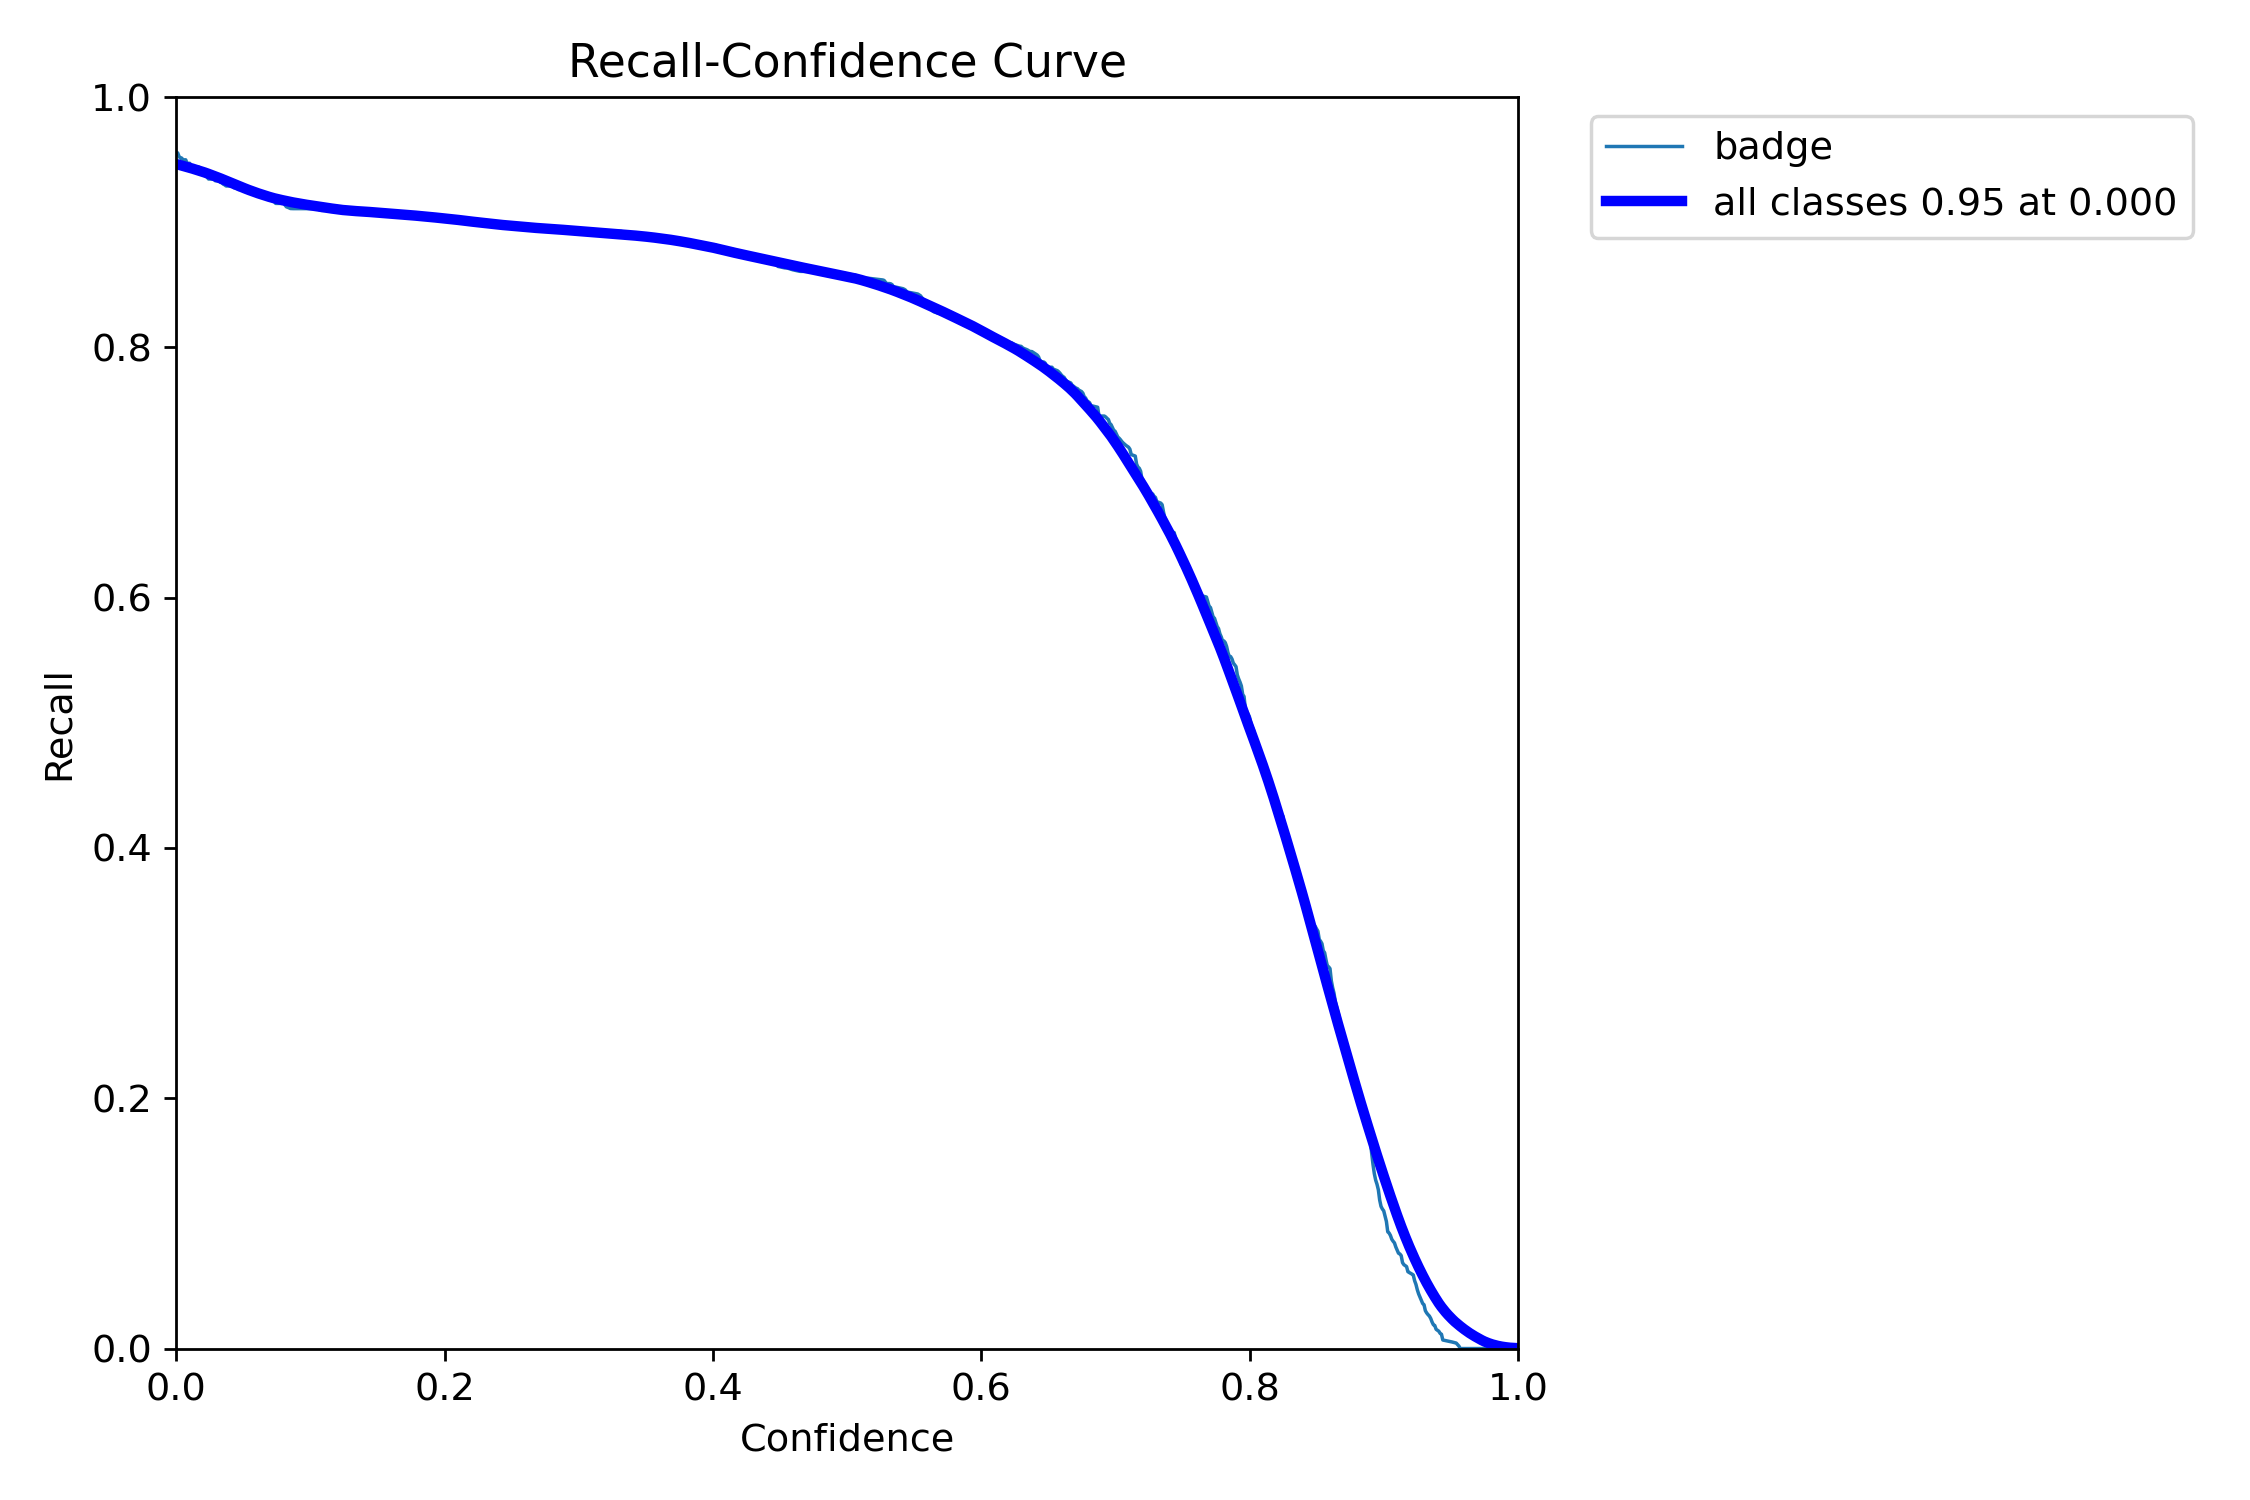

/content/runs/badge_detector/confusion_matrix.png


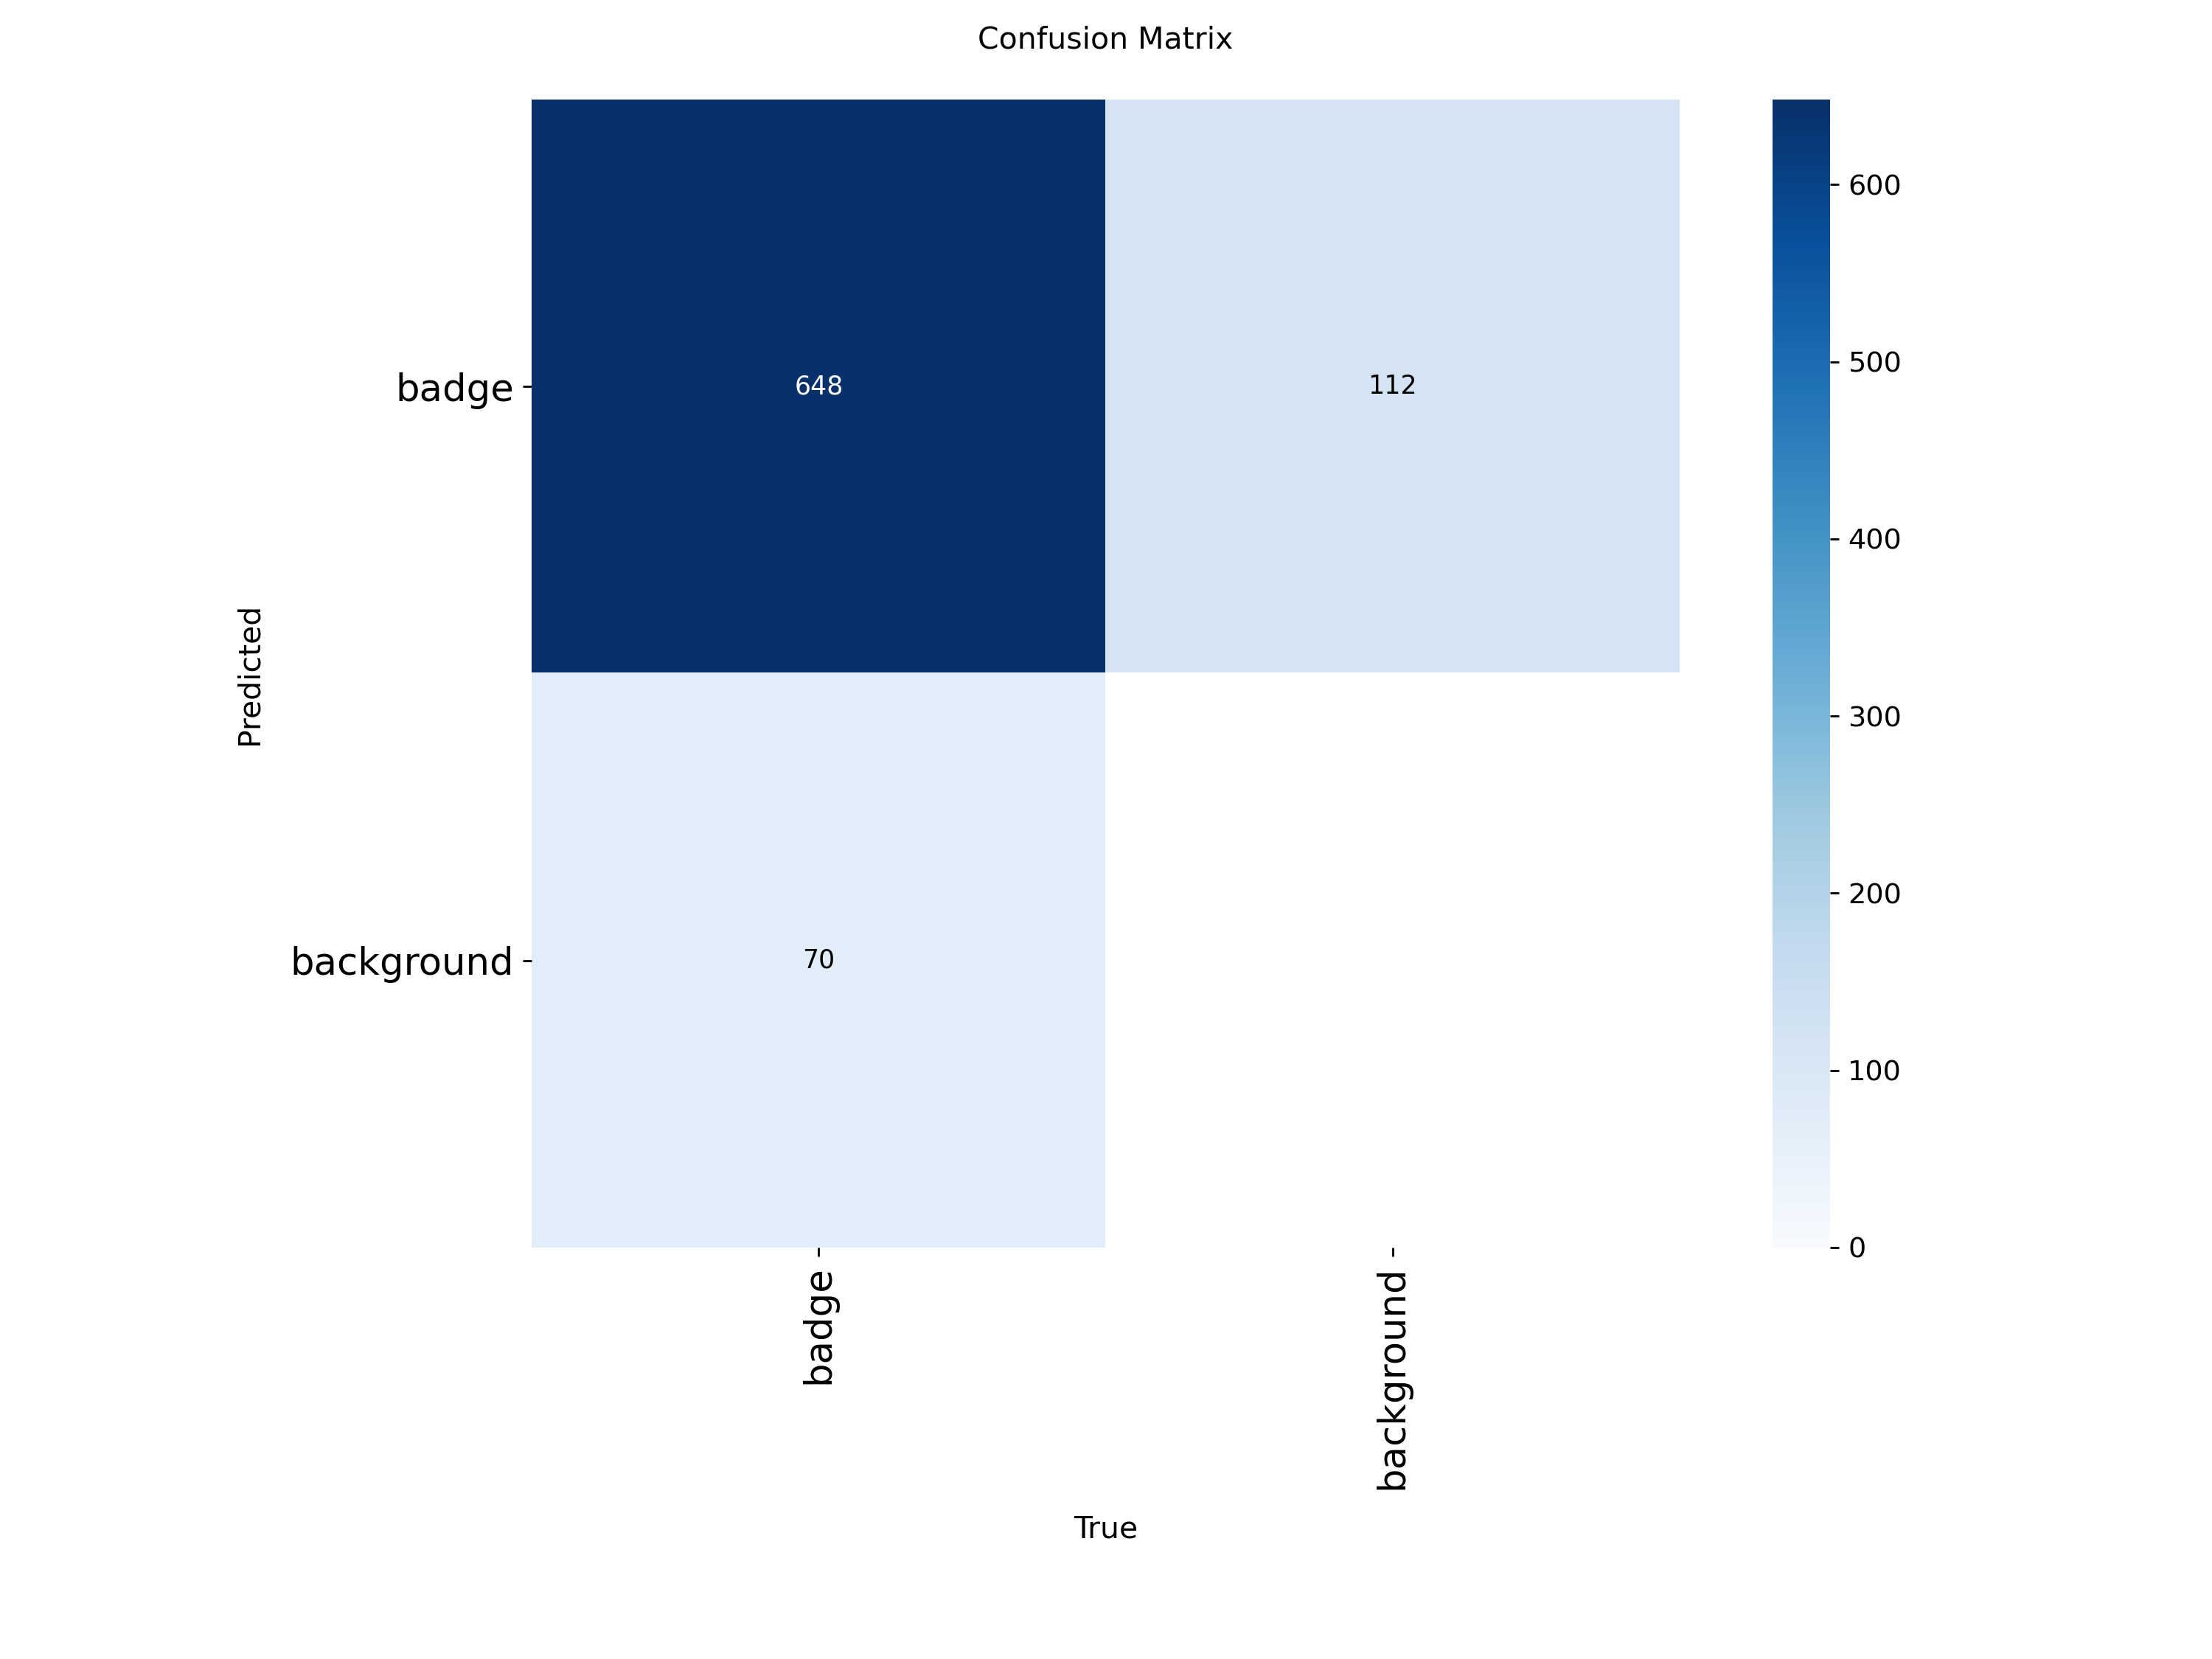

/content/runs/badge_detector/confusion_matrix_normalized.png


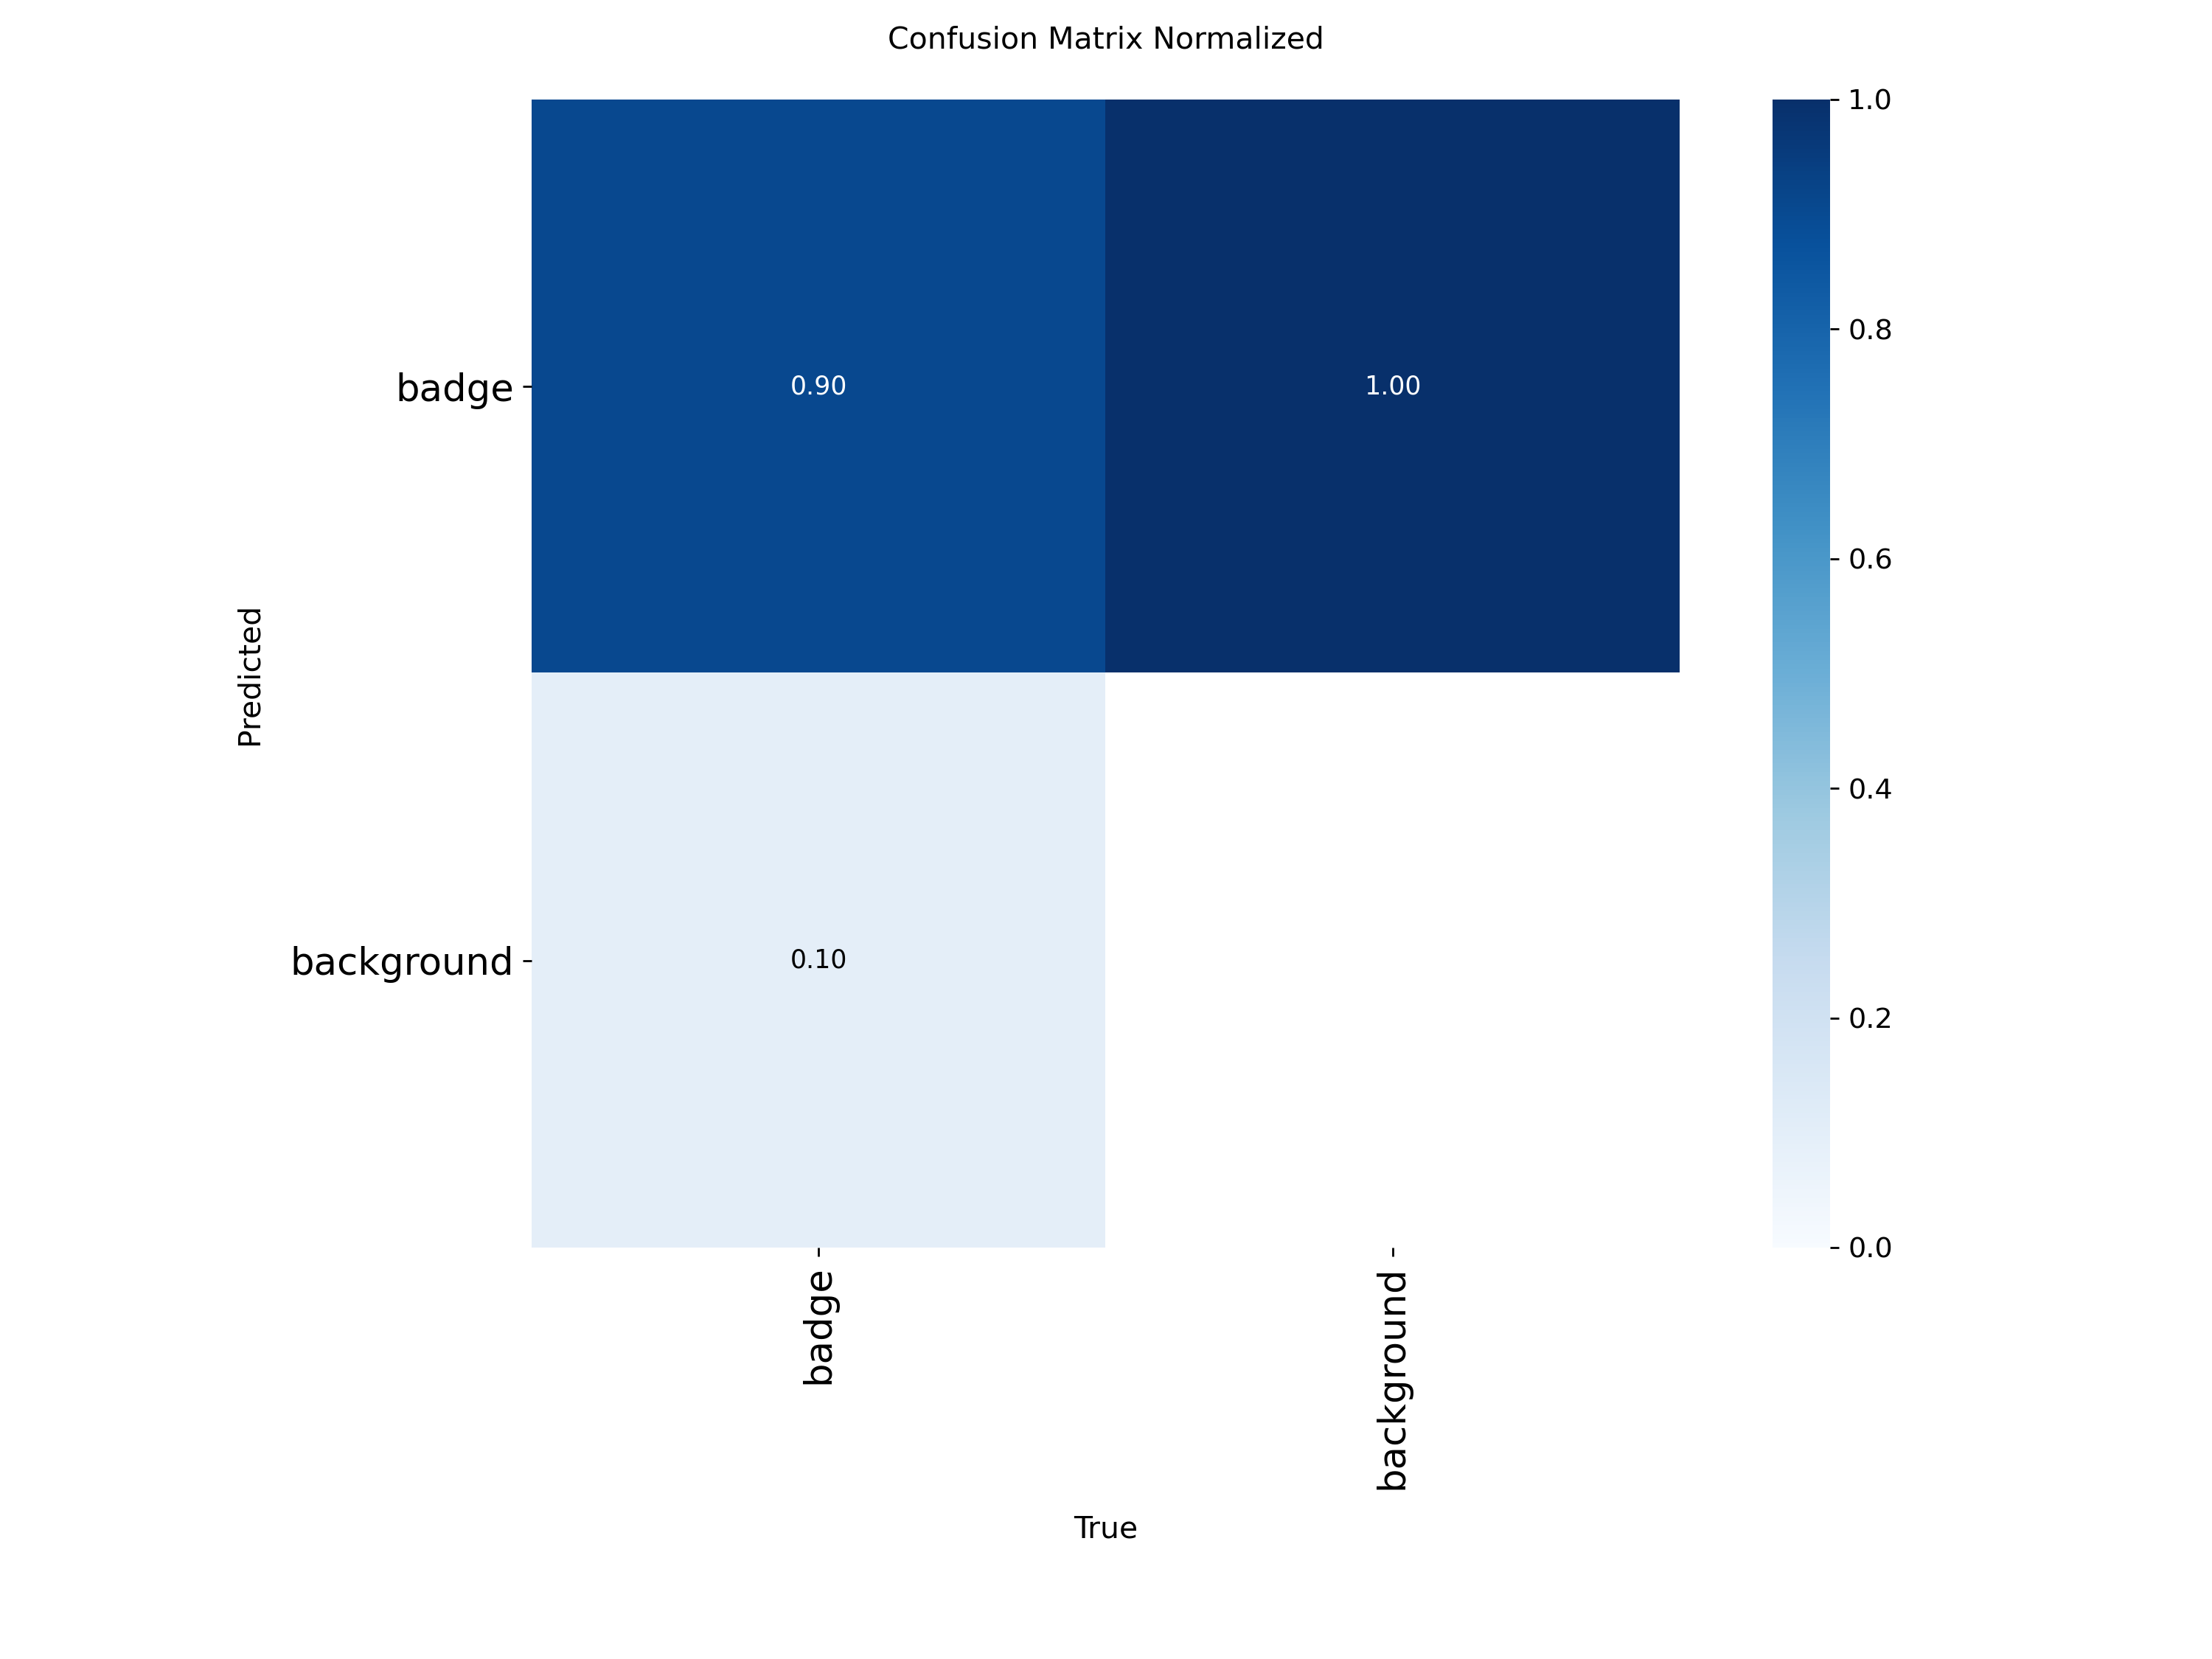

/content/runs/badge_detector/results.png


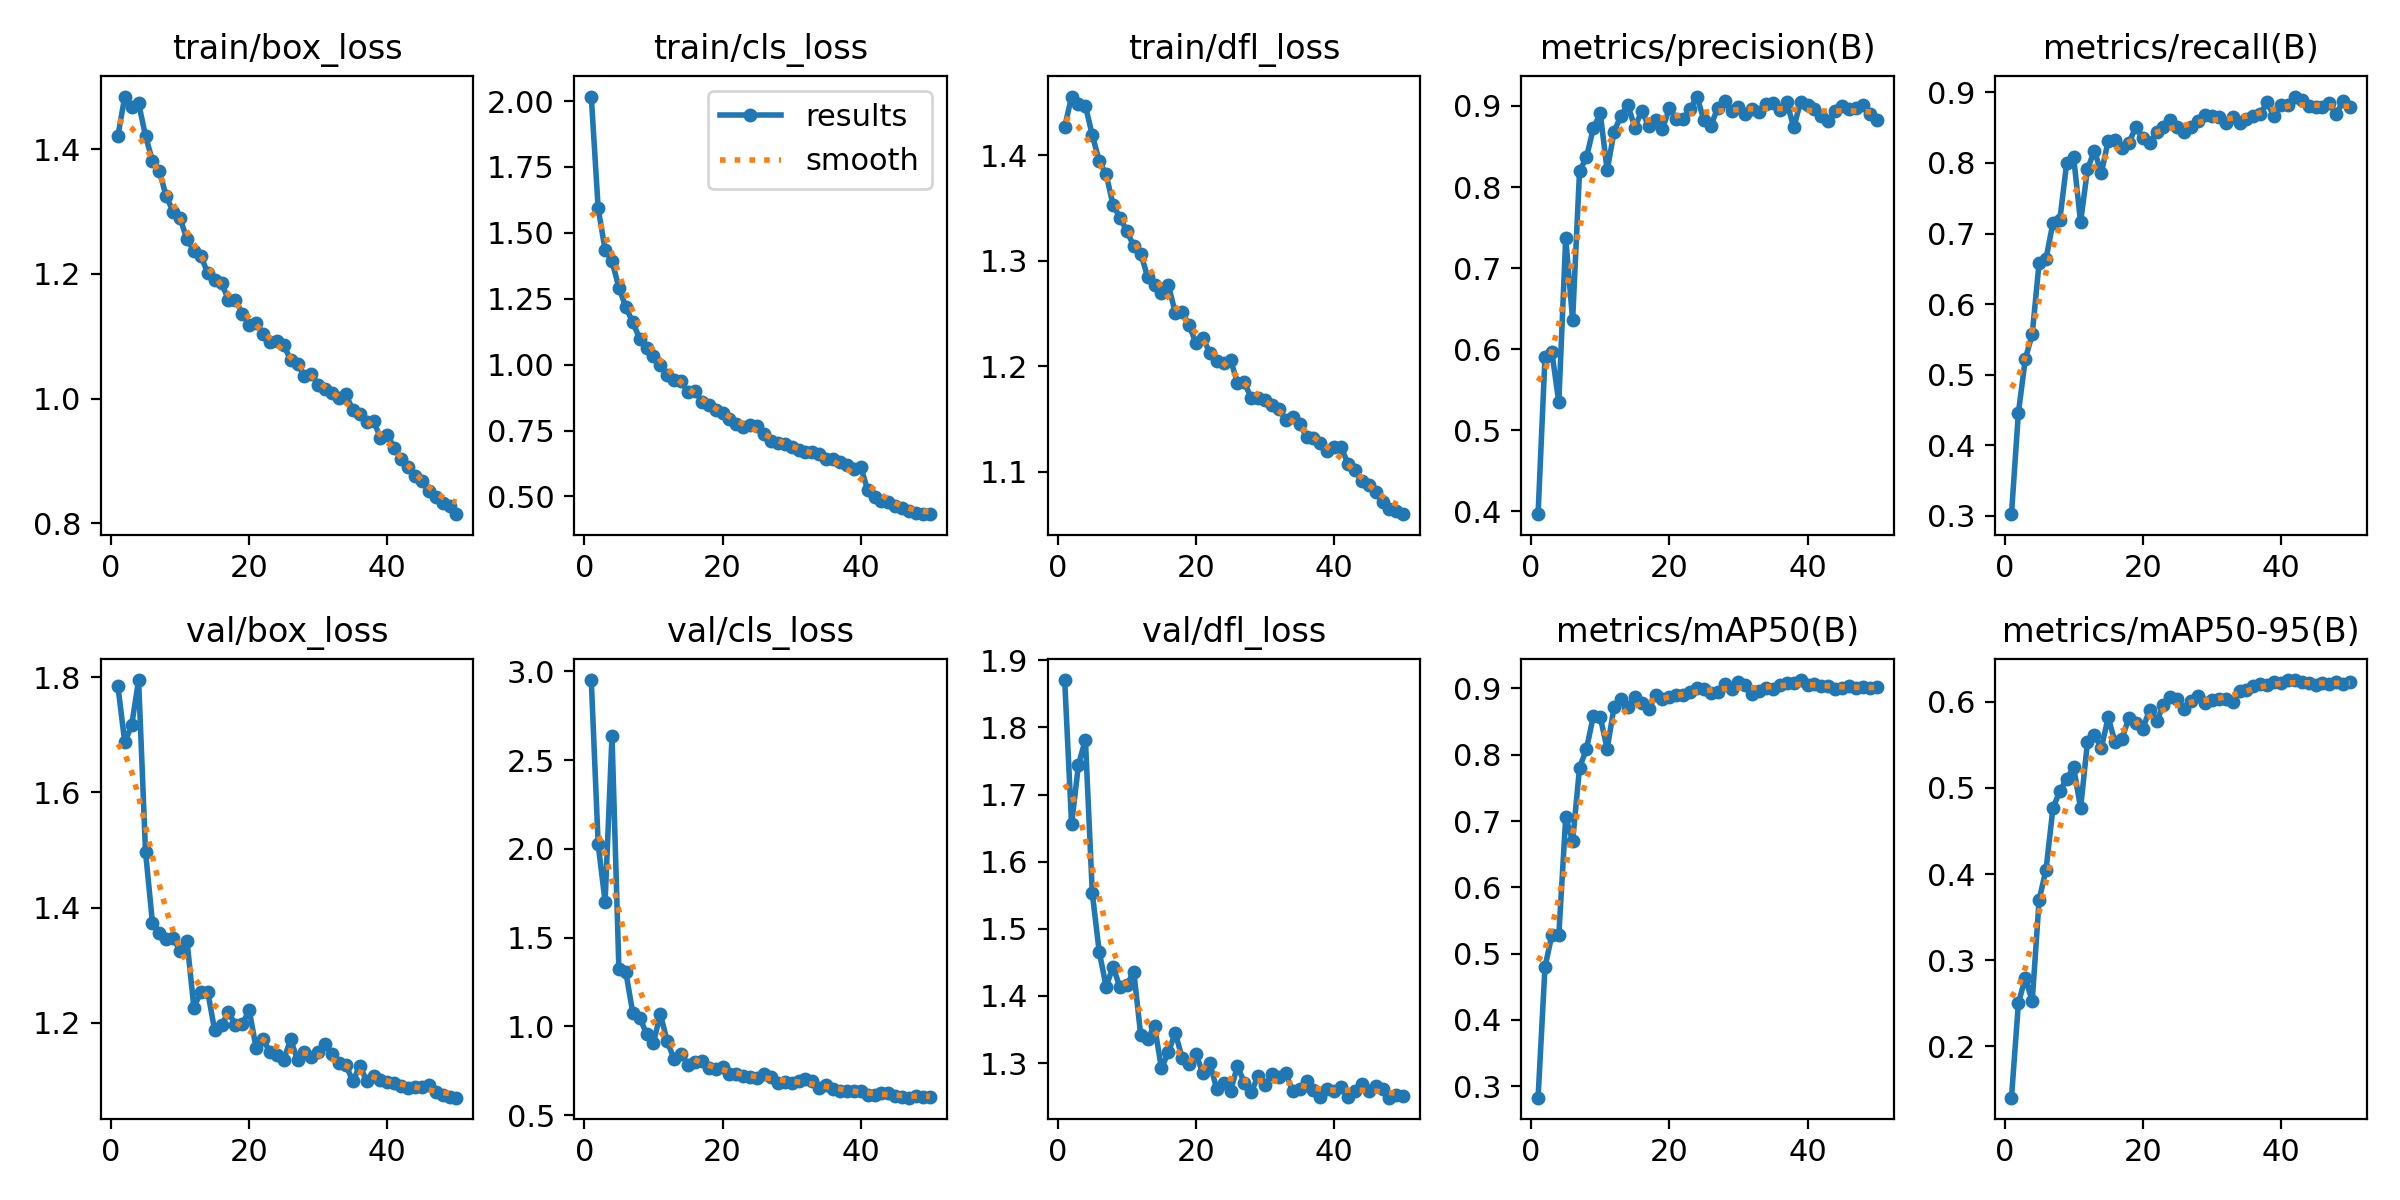

In [ ]:
from IPython.display import Image, display
import glob

plot_files = glob.glob('/content/runs/badge_detector/*.png')
for p in sorted(plot_files):
    print(p)
    display(Image(p, width=900))

## 6. Валидация на тестовой выборке

In [ ]:
from ultralytics import YOLO

model = YOLO(BEST_PT)
metrics = model.val(
    data=DATA_YAML,
    split='test',
    imgsz=IMGSZ,
    device=0,
    plots=True,
)

print('\n📊 Результаты на тестовой выборке:')
print(f'  Precision:  {metrics.results_dict.get("metrics/precision(B)", 0):.4f}')
print(f'  Recall:     {metrics.results_dict.get("metrics/recall(B)", 0):.4f}')
print(f'  mAP50:      {metrics.results_dict.get("metrics/mAP50(B)", 0):.4f}')
print(f'  mAP50-95:   {metrics.results_dict.get("metrics/mAP50-95(B)", 0):.4f}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 939.9±422.5 MB/s, size: 48.4 KB)
val: Scanning /content/dataset_merged/labels/test... 296 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 296/296 1.9Kit/s 0.2s
val: New cache created: /content/dataset_merged/labels/test.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 15, len(boxes) = 473. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.0it/s 4.7s
                   all        296        473       0.92      0.877      0.924      0.646
Speed: 2.5ms preprocess, 4.4ms inference, 0.0ms loss, 1.7ms postproces

## 7. Детектирование на изображениях

Выбери изображение для теста:


Saving test.jpg to test.jpg

image 1/1 /content/test.jpg: 640x480 1 badge, 44.2ms
Speed: 3.2ms preprocess, 44.2ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/detect_results/run


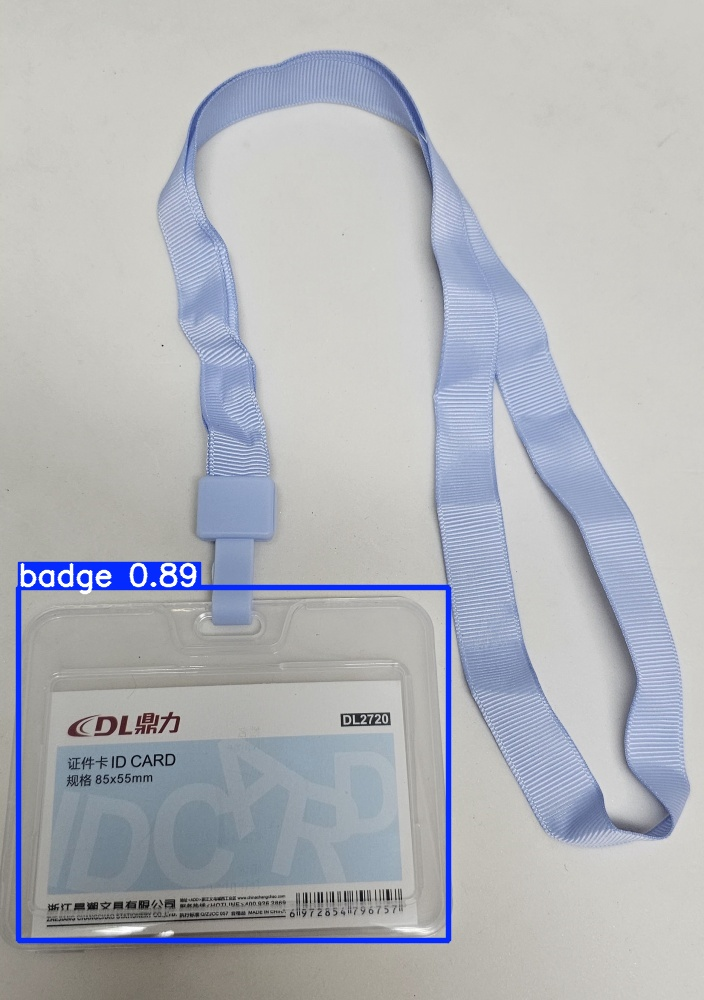

Найдено объектов: 1
  bbox=(18,587,448,940)  conf=0.890


In [ ]:
# ── 7a. Загрузить изображение с компьютера и проверить ─────────────────────
from google.colab import files
from IPython.display import Image, display
from ultralytics import YOLO
import cv2, os

print('Выбери изображение для теста:')
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

model = YOLO(BEST_PT)
results = model(img_path, conf=0.5, save=True, project='/content/detect_results', name='run', exist_ok=True)

# Показываем результат
result_img = f'/content/detect_results/run/{os.path.basename(img_path)}'
if os.path.exists(result_img):
    display(Image(result_img, width=800))

for r in results:
    print(f'Найдено объектов: {len(r.boxes)}')
    for box in r.boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        print(f'  bbox=({x1},{y1},{x2},{y2})  conf={conf:.3f}')

Показываю 6 случайных примеров из тестовой выборки:

image 1/1 /content/dataset_merged/images/test/badge-detection-full-ecqi4__test22_jpg.rf.097220d2f0e02a3a5808e7f0a1111357.jpg: 640x640 1 badge, 7.2ms
Speed: 1.5ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/detect_results/batch
badge-detection-full-ecqi4__test22_jpg.rf.097220d2f0e02a3a5808e7f0a1111357.jpg: 1 бейдж(ей)


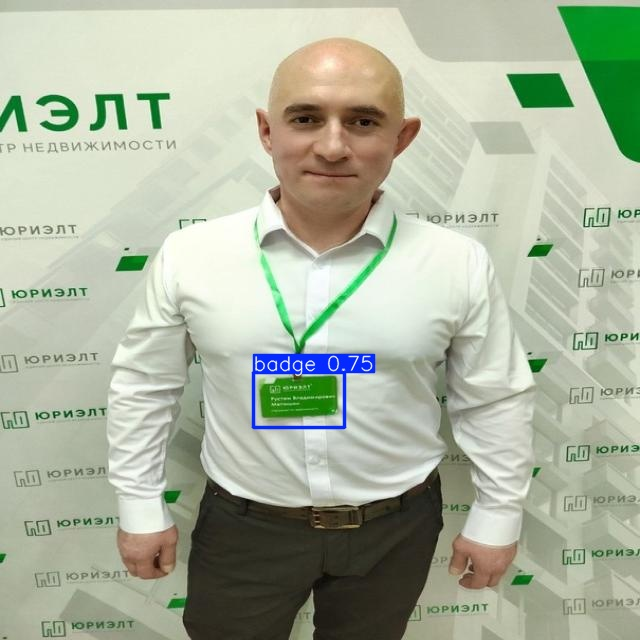


image 1/1 /content/dataset_merged/images/test/id-card-go7hc__IMG_20240708_034110_jpg.rf.f4cdd08698e06f185d31f64e07c4ec7a.jpg: 640x640 2 badges, 10.4ms
Speed: 2.4ms preprocess, 10.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/detect_results/batch
id-card-go7hc__IMG_20240708_034110_jpg.rf.f4cdd08698e06f185d31f64e07c4ec7a.jpg: 2 бейдж(ей)


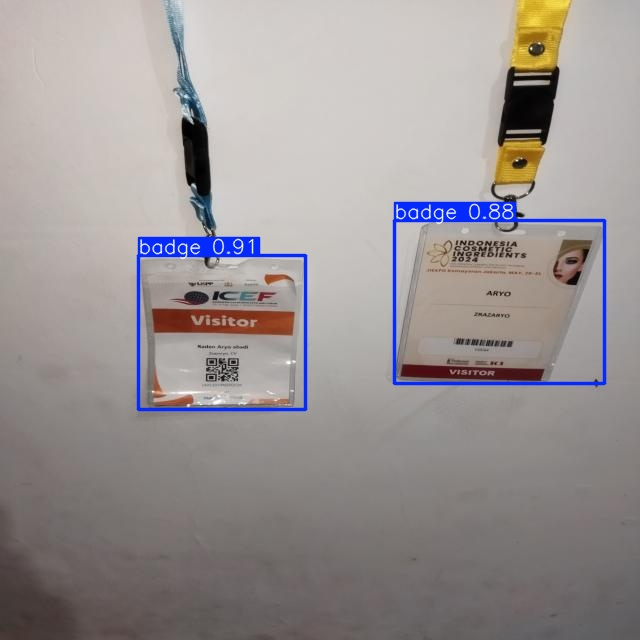


image 1/1 /content/dataset_merged/images/test/id-card-ecsnq__ID-image_25459_jpg.rf.7a9496ded2cf74d5c219781fe607e457.jpg: 640x640 2 badges, 9.0ms
Speed: 2.3ms preprocess, 9.0ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/detect_results/batch
id-card-ecsnq__ID-image_25459_jpg.rf.7a9496ded2cf74d5c219781fe607e457.jpg: 2 бейдж(ей)


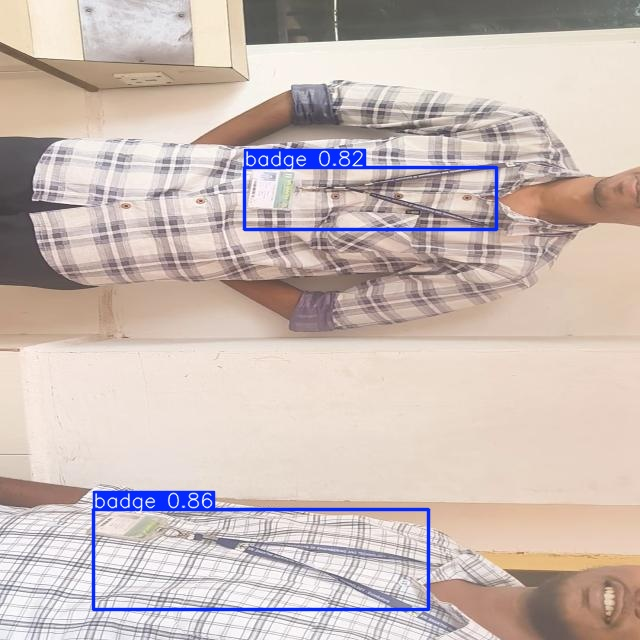


image 1/1 /content/dataset_merged/images/test/id-card-ecsnq__ID-image_25575_jpg.rf.7ac0876fb4d9c5faec2e0d9604b0b7e5.jpg: 640x640 2 badges, 9.2ms
Speed: 2.4ms preprocess, 9.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/detect_results/batch
id-card-ecsnq__ID-image_25575_jpg.rf.7ac0876fb4d9c5faec2e0d9604b0b7e5.jpg: 2 бейдж(ей)


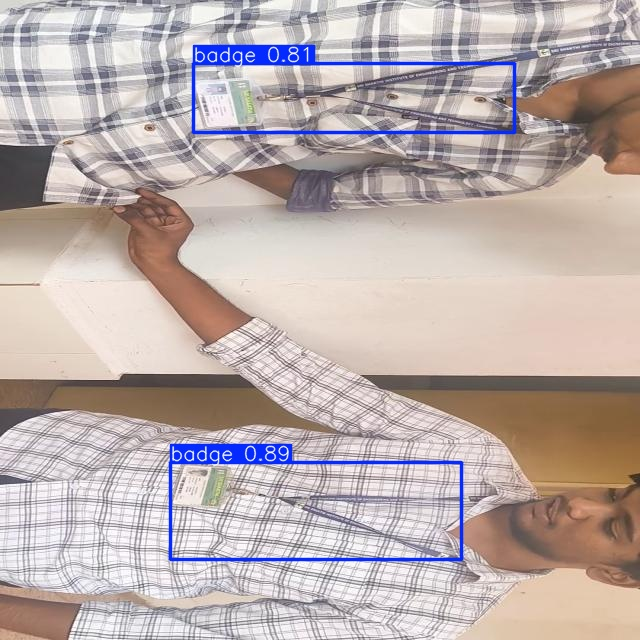


image 1/1 /content/dataset_merged/images/test/badge-detection-bx6ja__stock-photo-woman-wear-blank-white-vertical-badge-mockup-stand-isolated-name-tag-on-neck-and-chest-person-481317514_jpg.rf.65ea20119a5298837b1f168da18a90b3.jpg: 640x640 1 badge, 10.5ms
Speed: 5.7ms preprocess, 10.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/detect_results/batch
badge-detection-bx6ja__stock-photo-woman-wear-blank-white-vertical-badge-mockup-stand-isolated-name-tag-on-neck-and-chest-person-481317514_jpg.rf.65ea20119a5298837b1f168da18a90b3.jpg: 1 бейдж(ей)


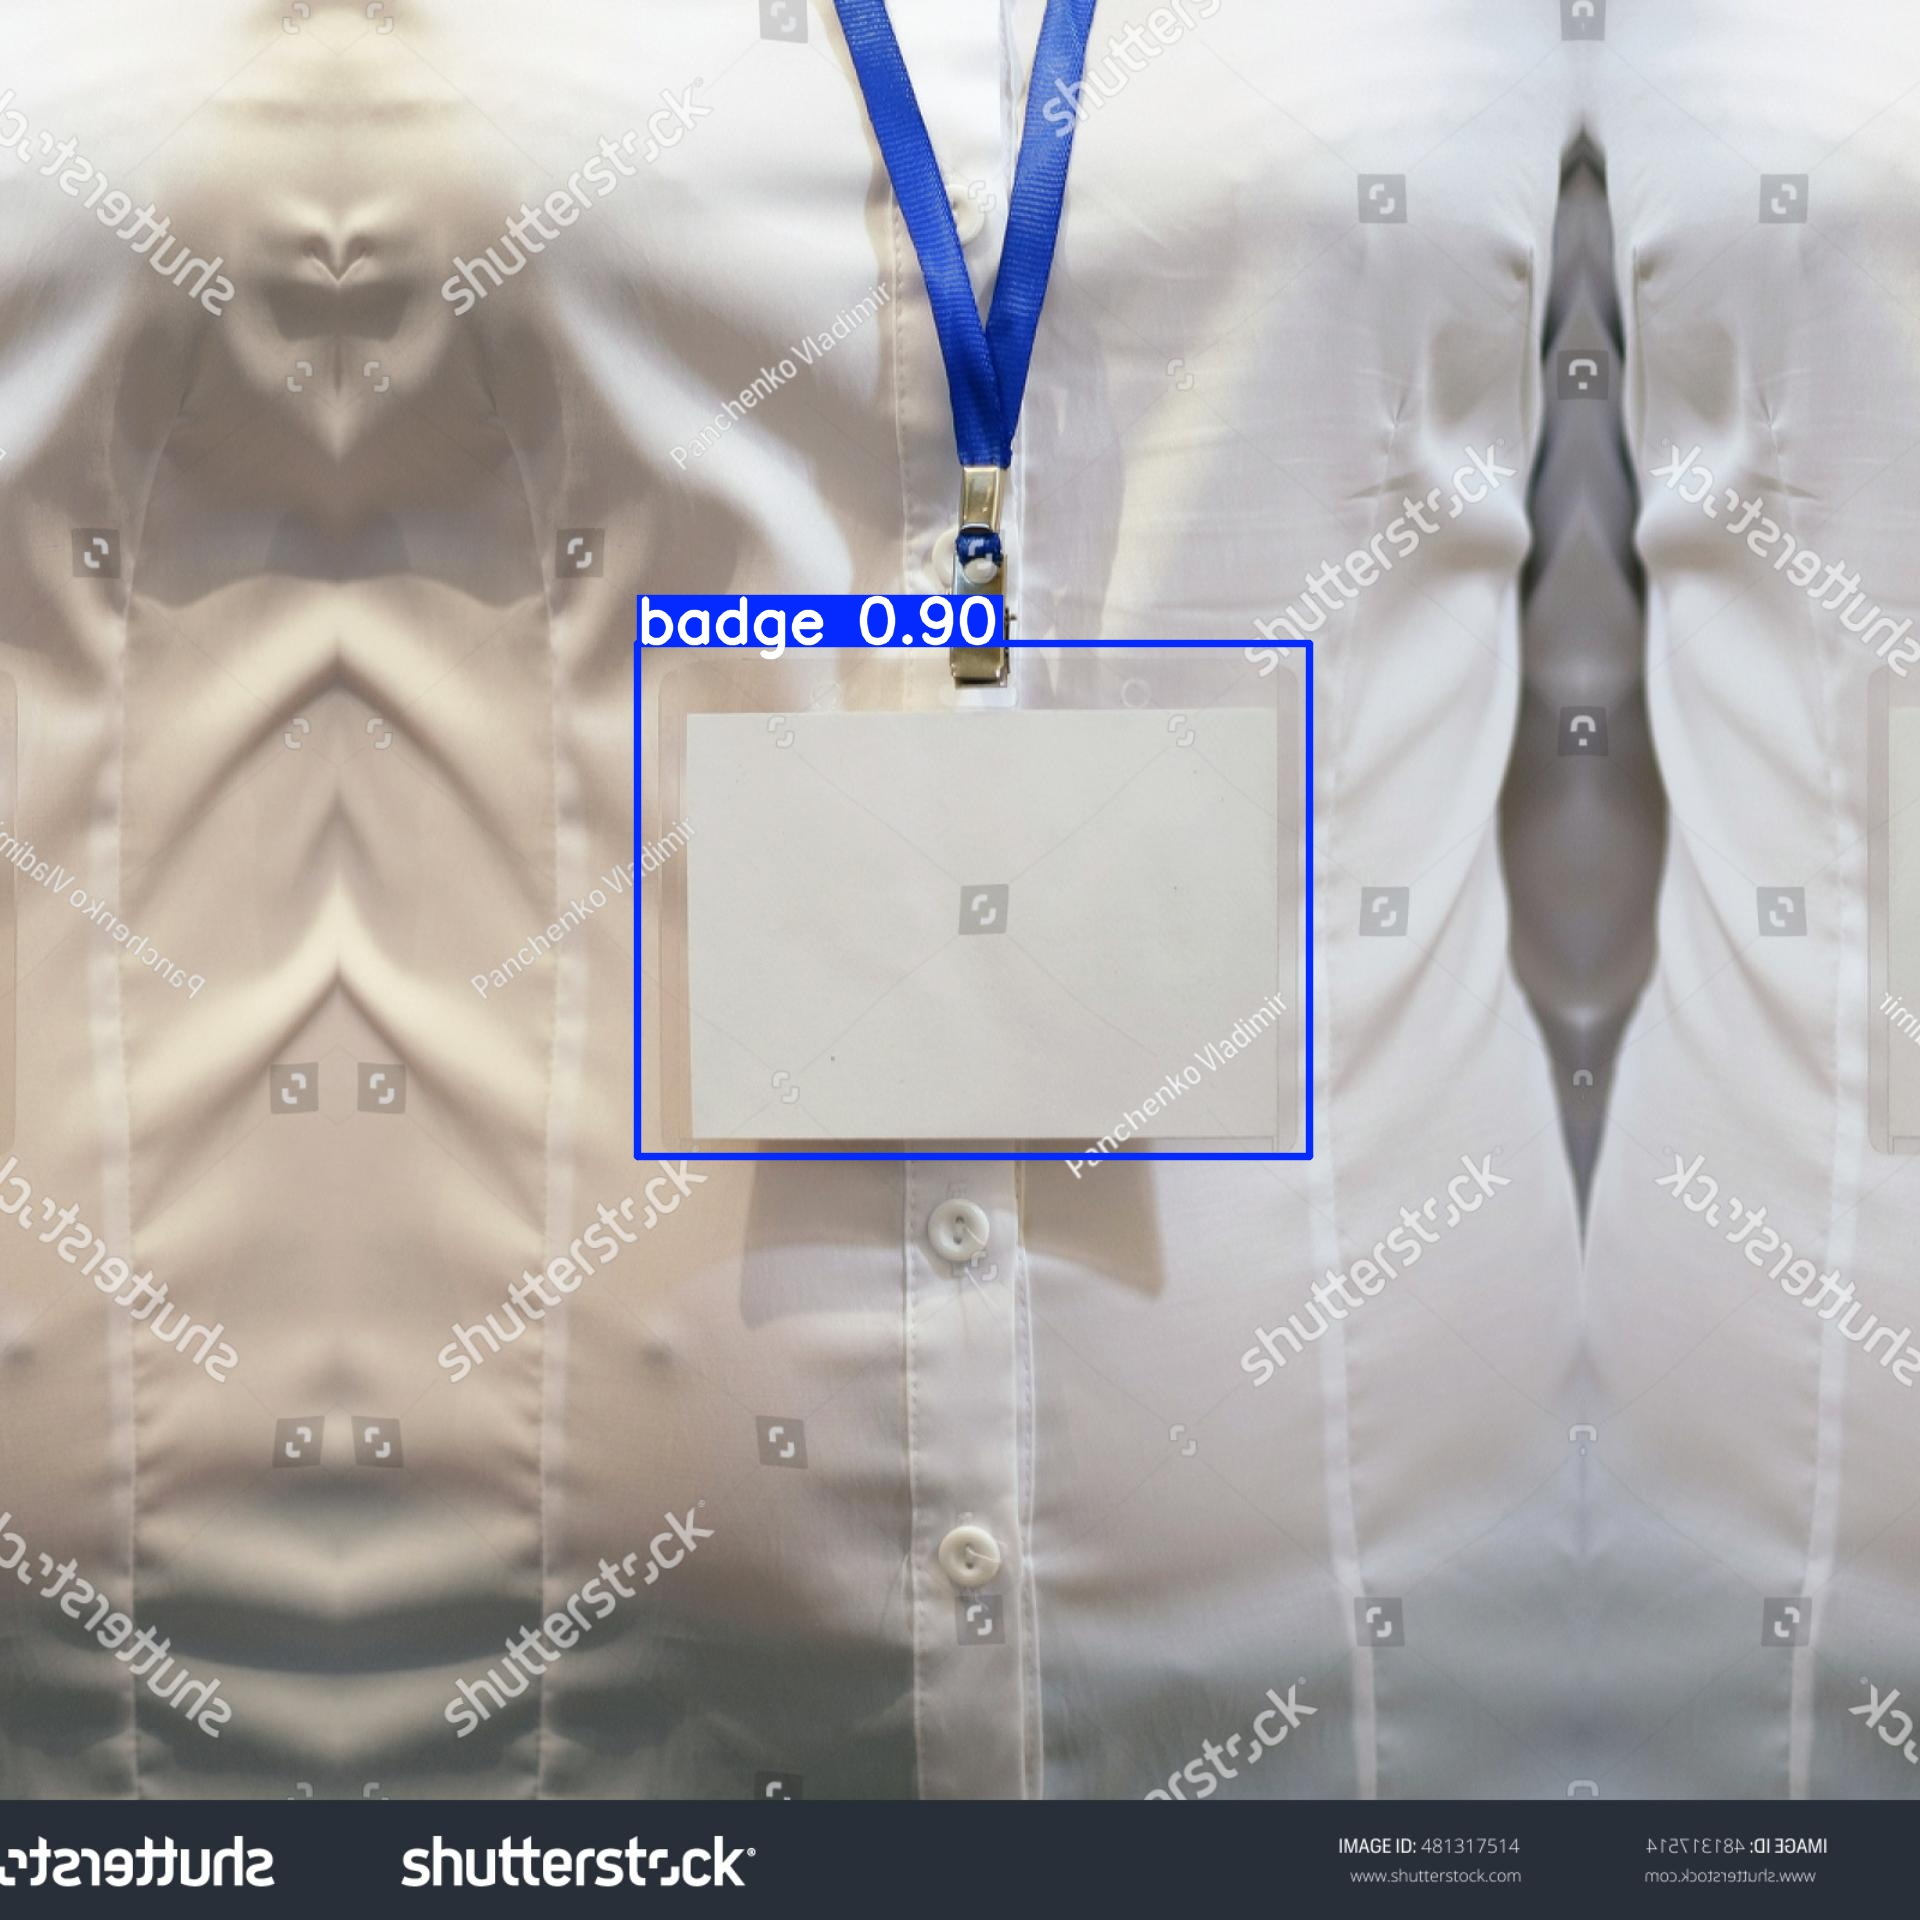


image 1/1 /content/dataset_merged/images/test/badge-detection-full-ecqi4__addpack_08_098_jpg.rf.47f12c16dfdb51b133f4754760ca5dfb.jpg: 640x640 1 badge, 10.2ms
Speed: 2.4ms preprocess, 10.2ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/detect_results/batch
badge-detection-full-ecqi4__addpack_08_098_jpg.rf.47f12c16dfdb51b133f4754760ca5dfb.jpg: 1 бейдж(ей)


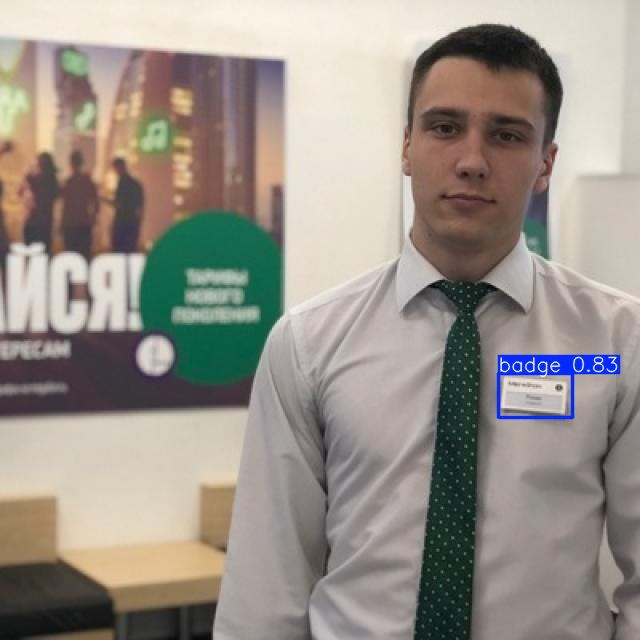

In [ ]:
# ── 7b. Детекция на тестовых изображениях из датасета ─────────────────────
import random
from pathlib import Path
from IPython.display import Image, display
from ultralytics import YOLO

model = YOLO(BEST_PT)
test_imgs = list(Path('/content/dataset_merged/images/test').glob('*.jpg'))

if not test_imgs:
    test_imgs = list(Path('/content/dataset_merged/images/train').glob('*.jpg'))

samples = random.sample(test_imgs, min(6, len(test_imgs)))
print(f'Показываю {len(samples)} случайных примеров из тестовой выборки:')

for img_path in samples:
    results = model(str(img_path), conf=0.5, save=True,
                    project='/content/detect_results', name='batch', exist_ok=True)
    out_path = f'/content/detect_results/batch/{img_path.name}'
    if Path(out_path).exists():
        n = len(results[0].boxes)
        print(f'{img_path.name}: {n} бейдж(ей)')
        display(Image(out_path, width=600))

## 8. Сохранение модели на Google Drive / скачивание

In [ ]:
# ── Скачать best.pt на компьютер ──────────────────────────────────────────
from google.colab import files
files.download(BEST_PT)
print(f'✅ Скачивается: {BEST_PT}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Скачивается: /content/runs/badge_detector/weights/best.pt


In [ ]:
# ── Сохранить на Google Drive (рекомендуется — Colab сбрасывает файлы!) ───
from google.colab import drive
import shutil

drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/badge_detector'
os.makedirs(save_dir, exist_ok=True)

# Веса
shutil.copy(BEST_PT, f'{save_dir}/best.pt')

# Все результаты (графики, метрики)
shutil.copytree('/content/runs/badge_detector', f'{save_dir}/training_results', dirs_exist_ok=True)

print(f'✅ Всё сохранено в Google Drive: {save_dir}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Всё сохранено в Google Drive: /content/drive/MyDrive/badge_detector


## 9. Использование скачанной модели локально
После скачивания `best.pt` клади его в папку `yolo/runs/badge_detector/weights/` и запускай:
```bash
python yolo/detect.py ./yolo/runs/badge_detector/weights/best.pt test.jpg
```